# RFM in Action: Behavioral Segmentation for E-Commerce
### Phase 3 — Cohort Retention Analysis

**Goal:** Quantify customer longevity patterns and validate whether RFM segments correspond to meaningful retention differences.

In this phase, I analyze customer retention dynamics using cohort-based methods. This analysis uses the cleaned transactional table from Phase 1 and the RFM segments defined in Phase 2. The objective is to quantify how long customers remain active after their first purchase, identify churn patterns over time, and compare retention behavior across previously defined RFM segments.

## Part A: Feature Design

I assign each customer to a cohort based on their first purchase month. I then construct a monthly activity table at the customer-month grain to track ongoing engagement. From this, I compute customers_active and cohort_size metrics to derive retention rates as a function of months since cohort start.

Similar to Phase 2, these queries were handled in Microsoft SQL Server.

**`cohort_activity`:**

``` sql
-- create cohort_activity table
-- cohorts: assign each user to a cohort (first purchase)
WITH cohorts AS (
	SELECT 
		CustomerID,
		DATEFROMPARTS(
			YEAR(MIN(InvoiceDate)),
			MONTH(MIN(InvoiceDate)),
			1
		) AS cohort_month_start
	FROM dbo.transactions_enriched
	GROUP BY CustomerID
),
cohort_sizes AS (
	SELECT
		cohort_month_start,
		COUNT(DISTINCT CustomerID) AS cohort_size
	FROM cohorts
	GROUP BY cohort_month_start
),
-- activity: create monthly activity records at customer-month grain
activity AS (
	SELECT 
		CustomerID,
		DATEFROMPARTS(
			YEAR(InvoiceDate),
			MONTH(InvoiceDate),
			1
		) AS activity_month_start
	FROM dbo.transactions_enriched
	GROUP BY CustomerID, YEAR(InvoiceDate), MONTH(InvoiceDate)
)
SELECT
	c.cohort_month_start,
	a.activity_month_start,
	DATEDIFF(MONTH, c.cohort_month_start, a.activity_month_start) AS months_since_cohort,
	COUNT(DISTINCT a.CustomerID) AS customers_active,
	s.cohort_size,
	((COUNT(DISTINCT a.CustomerID) * 1.0) / NULLIF(s.cohort_size, 0)) * 100 AS retention_rate
FROM cohorts c
JOIN activity a
	ON c.CustomerID = a.CustomerID
JOIN cohort_sizes s
	ON c.cohort_month_start = s.cohort_month_start
WHERE a.activity_month_start >= c.cohort_month_start
GROUP BY c.cohort_month_start, a.activity_month_start, s.cohort_size;
```

**`cohort_activity_by_segment`:**

``` sql
WITH cohorts AS (
	SELECT 
		CustomerID,
		DATEFROMPARTS(
			YEAR(MIN(InvoiceDate)),
			MONTH(MIN(InvoiceDate)),
			1
		) AS cohort_month_start
	FROM dbo.transactions_enriched
	GROUP BY CustomerID
),
activity AS (
	SELECT 
		CustomerID,
		DATEFROMPARTS(
			YEAR(InvoiceDate),
			MONTH(InvoiceDate),
			1
		) AS activity_month_start
	FROM dbo.transactions_enriched
	GROUP BY CustomerID, YEAR(InvoiceDate), MONTH(InvoiceDate)
),
monthly_cust_activity  AS (
	SELECT 
		c.CustomerID,
		c.cohort_month_start,
		a.activity_month_start,
		DATEDIFF(MONTH, c.cohort_month_start, a.activity_month_start) AS months_since_cohort
	FROM cohorts c
	JOIN activity a
	ON c.CustomerID = a.CustomerID
),
cust_activity AS (
	SELECT
		rfm.CUSTOMERID,
		mca.cohort_month_start,
		mca.activity_month_start,
		mca.months_since_cohort,
		rfm.segment
	FROM dbo.rfm rfm
	JOIN monthly_cust_activity mca
		ON rfm.CUSTOMERID = mca.CustomerID
),
active_customers AS (
	SELECT
		segment,
		cohort_month_start,
		months_since_cohort,
		COUNT(DISTINCT CUSTOMERID) AS customers_active
	FROM cust_activity
	GROUP BY segment, cohort_month_start, months_since_cohort
),
cohort_sizes AS (
	SELECT
		segment,
		cohort_month_start,
		COUNT(DISTINCT CUSTOMERID) AS cohort_size
	FROM cust_activity
	WHERE months_since_cohort = 0
	GROUP BY segment, cohort_month_start
)
SELECT 
	a.segment,
	a.cohort_month_start,
	DATEADD(MONTH, a.months_since_cohort, a.cohort_month_start) AS activity_month_start,
	a.months_since_cohort,
	a.customers_active,
	s.cohort_size,
	CAST(1.0 * a.customers_active / NULLIF(s.cohort_size, 0) AS DECIMAL(18, 4)) AS retention_rate
INTO dbo.cohort_activity_by_segment
FROM active_customers a
JOIN cohort_sizes s
	ON s.segment = a.segment
	AND s.cohort_month_start = a.cohort_month_start;
```

## Part B: Visualizing Overall Retention

In [1]:
# setup
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

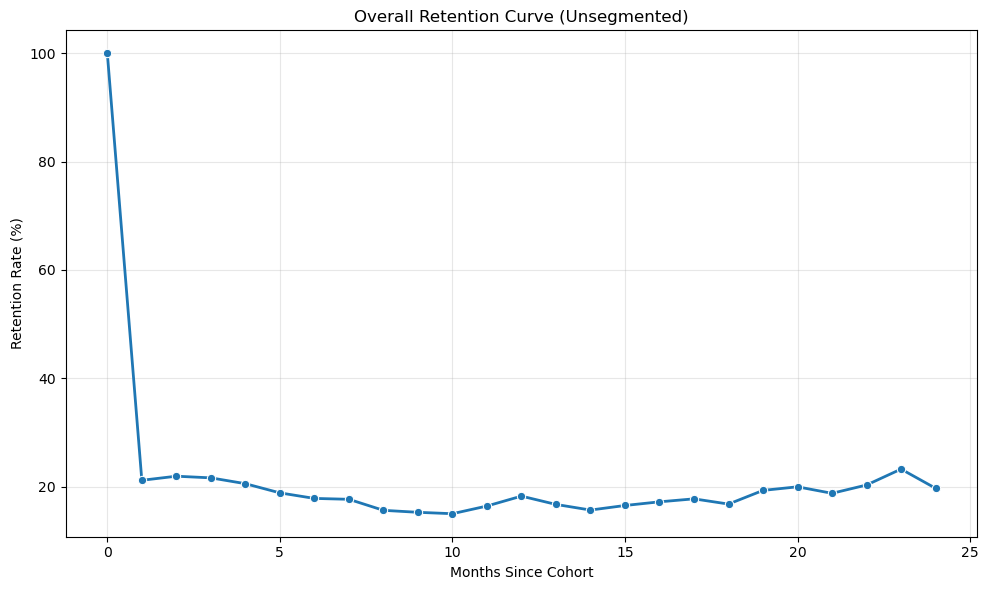

In [2]:
# overall retention
cohort_activity = pd.read_csv('cohort_activity.csv')

# Aggregate to overall retention by months_since_cohort
overall = (
    cohort_activity.groupby('months_since_cohort')['retention_rate']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data = overall,
    x = 'months_since_cohort',
    y = 'retention_rate',
    marker = 'o',
    linewidth=2,
    errorbar=None
)

plt.title('Overall Retention Curve (Unsegmented)')
plt.xlabel('Months Since Cohort')
plt.ylabel('Retention Rate (%)')
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

I aggregate retention across all cohorts to produce an overall retention curve. The plot shows a steep drop after the first month, followed by a long tail of low but stable retention. This pattern indicates that most customers are one-time purchasers, while a smaller subset remains engaged long-term.

## Part C: Examining Retention Across Segments

In [3]:
segment_activity = pd.read_csv('cohort_activity_by_segment.csv')
segment_activity.head()

,segment,cohort_month_start,activity_month_start,months_since_cohort,customers_active,cohort_size,retention_rate
0,Loyal,2009-12-01,2010-03-01,3,89,183,0.4863
1,Loyal,2009-12-01,2010-06-01,6,62,183,0.3388
2,Loyal,2009-12-01,2010-09-01,9,71,183,0.3880
3,Loyal,2009-12-01,2010-12-01,12,67,183,0.3661
4,Loyal,2010-03-01,2010-06-01,3,33,93,0.3548


To understand behavioral differences, I join RFM segments with cohort activity and compute segment-specific retention rates. This enables comparison of engagement longevity across behavioral groups defined in the segmentation phase.

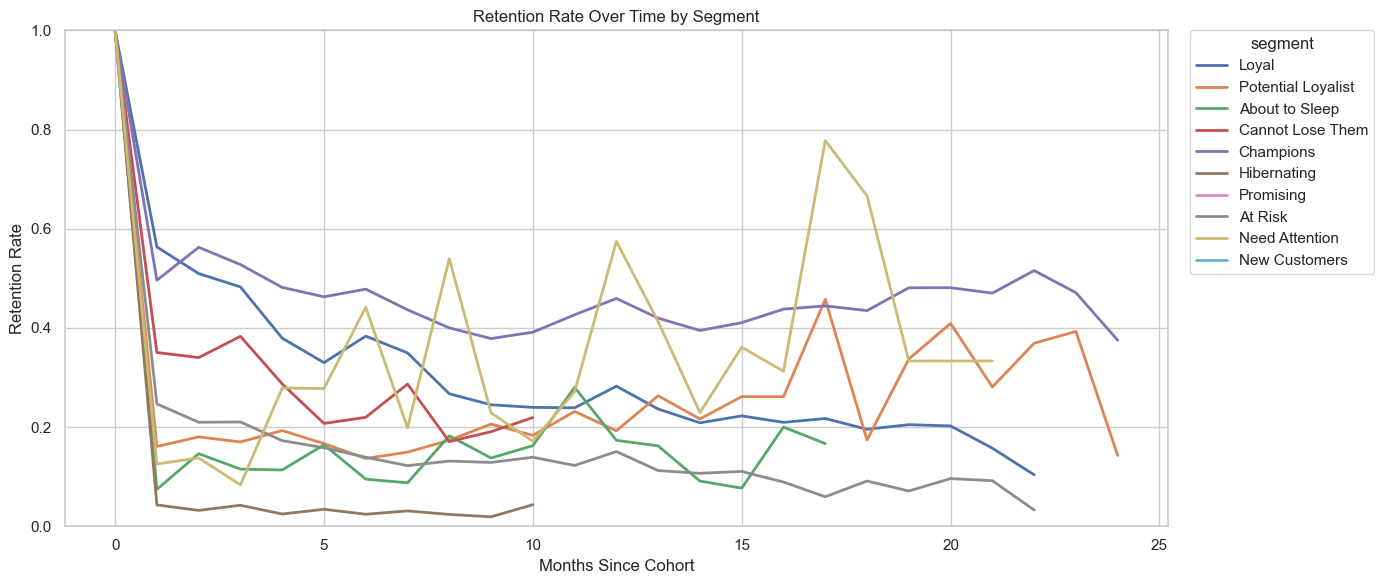

In [4]:
# plot each segment's cohort activity

sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (14,6))
ax = sns.lineplot(
    data = segment_activity,  # must be long form: months_since_cohort, retention_rate, segment
    x = 'months_since_cohort',
    y = 'retention_rate',
    hue = 'segment',
    linewidth = 2,
    marker = None,
    errorbar = None
)

ax.set_title('Retention Rate Over Time by Segment')
ax.set_xlabel('Months Since Cohort')
ax.set_ylabel('Retention Rate')
ax.set_ylim(0, 1)

# Put legend outside
ax.legend(title = 'segment', bbox_to_anchor = (1.02, 1), loc= 'upper left', borderaxespad = 0)

plt.tight_layout()
plt.show()

Plotting retention curves per segment reveals that Champions and Loyal customers maintain substantially higher long-term retention, while At Risk and Hibernating segments rapidly churn. This confirms that RFM segmentation meaningfully separates customers by expected lifetime value.

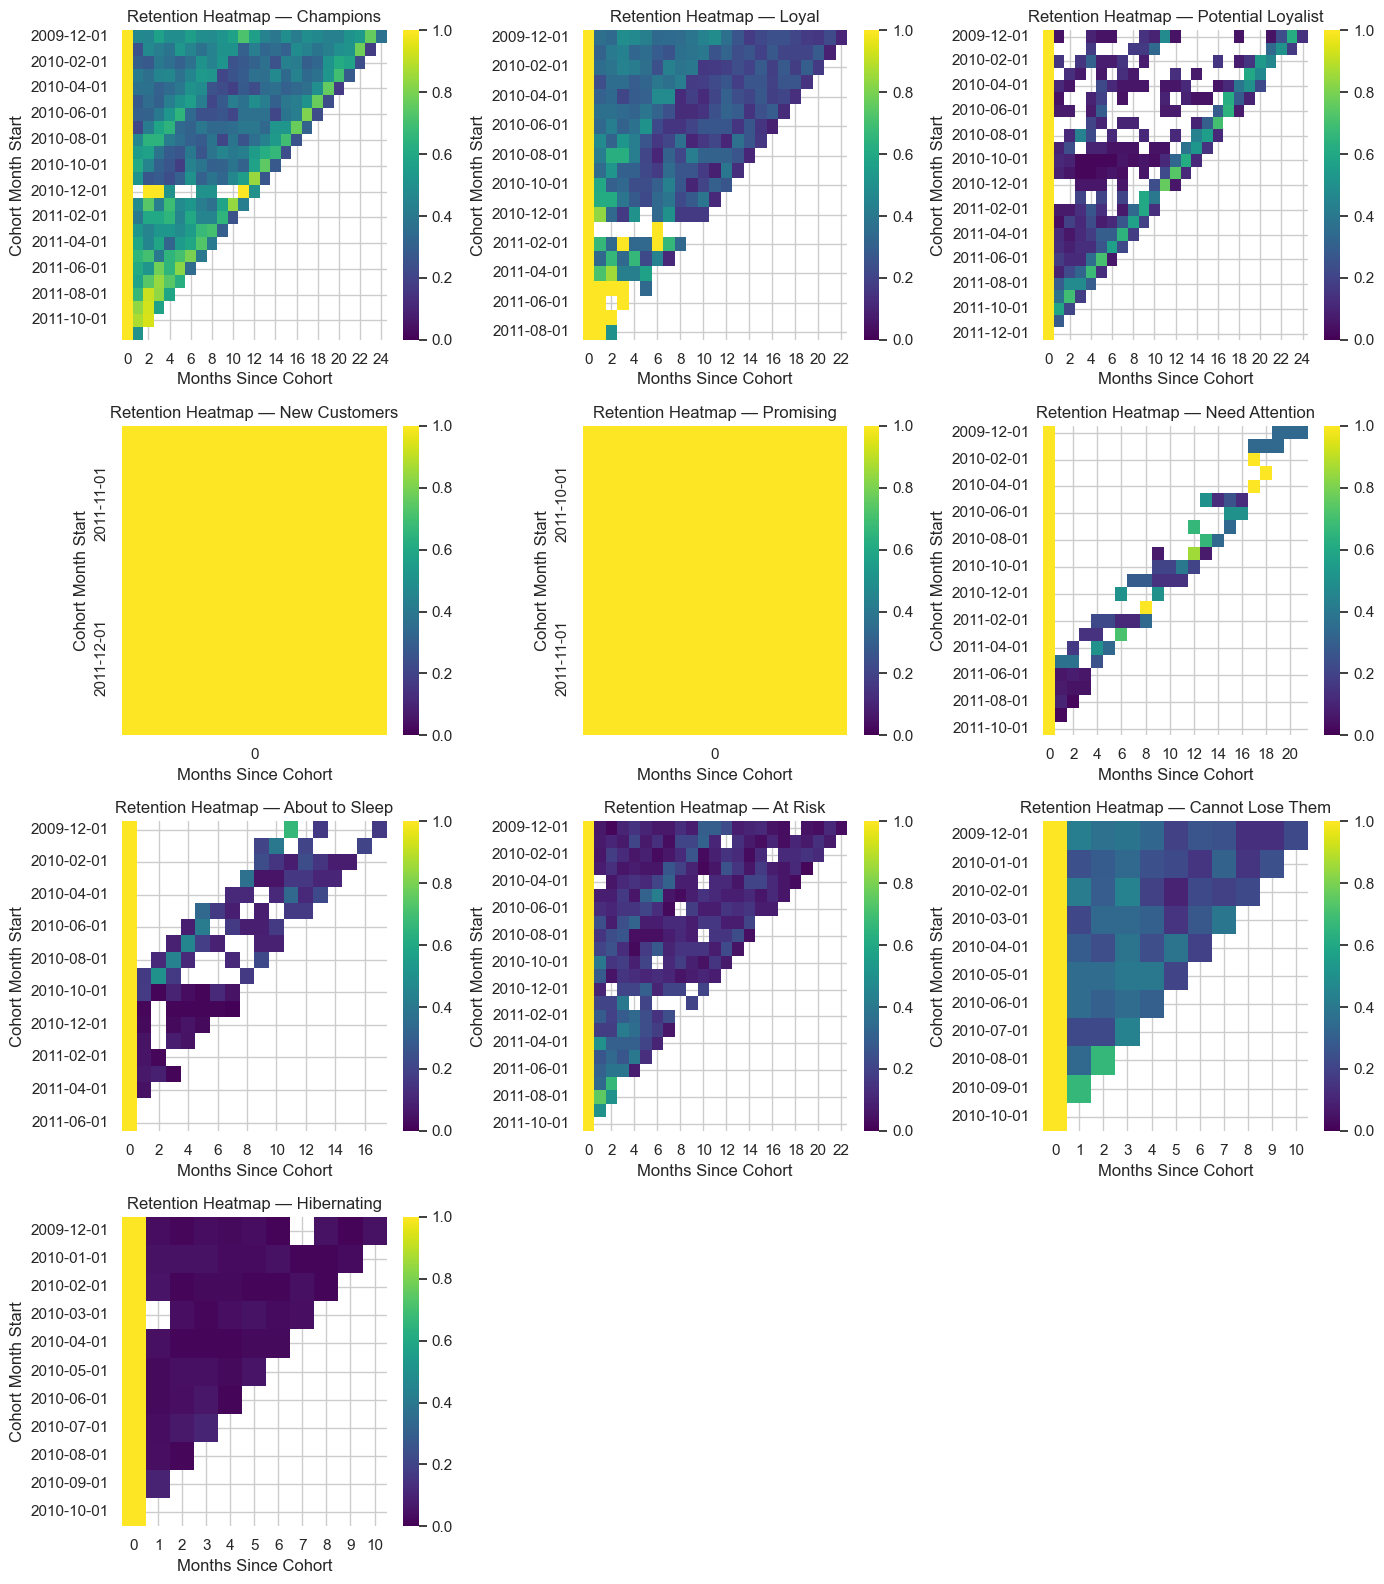

In [5]:
segment_activity_hm = segment_activity.copy()
segment_activity_hm = segment_activity_hm.sort_values(
    ['segment', 'cohort_month_start', 'months_since_cohort']
)

segments = [
    'Champions',
    'Loyal',
    'Potential Loyalist',
    'New Customers',
    'Promising',
    'Need Attention',
    'About to Sleep',
    'At Risk',
    'Cannot Lose Them',
    'Hibernating'
]
n_segments = len(segments)

fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()  # make indexing easier

for ax, seg in zip(axes, segments):
    pivot = segment_activity_hm[segment_activity_hm['segment'] == seg].pivot_table(
        index = 'cohort_month_start',
        columns = 'months_since_cohort',
        values = 'retention_rate',
        aggfunc = 'mean'
    )
    
    sns.heatmap(
        pivot,
        cmap = 'viridis',
        vmin = 0,
        vmax = 1,
        ax = ax
    )
    ax.set_title(f'Retention Heatmap — {seg}')
    ax.set_xlabel('Months Since Cohort')
    ax.set_ylabel('Cohort Month Start')

# Turn off any unused subplot axes
for ax in axes[n_segments:]:
    ax.axis('off')


plt.tight_layout()
plt.show()

I visualize retention using cohort heatmaps for each segment, where color intensity represents retention strength across cohort months. These heatmaps illustrate both cohort consistency over time and differences in retention stability across behavioral segments.

C:\Users\chynn\AppData\Local\Temp\ipykernel_28204\1893920726.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


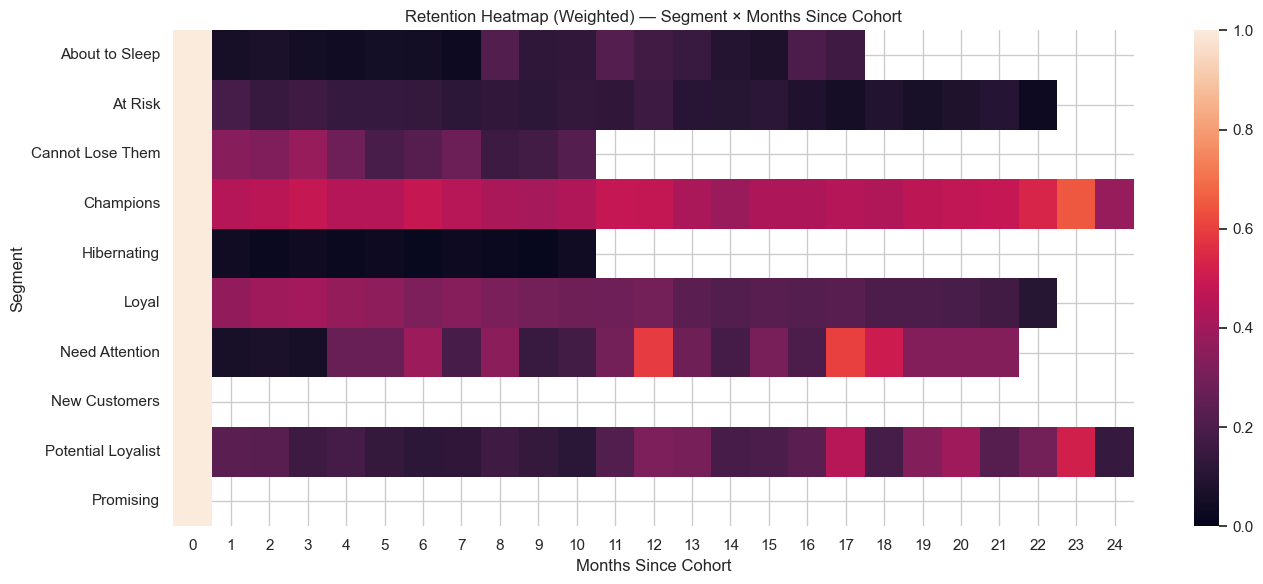

In [6]:
segment_activity_sum = segment_activity.copy()

# Weighted retention by cohort_size
grouped = (
    segment_activity_sum.groupby(['segment', 'months_since_cohort'], as_index = False)
    .apply(lambda g: pd.Series({
        'weighted_retention': (g['customers_active'].sum() / g['cohort_size'].sum())
    }))
    .reset_index(drop = True)
)

pivot = grouped.pivot(index = 'segment', columns = 'months_since_cohort', values = 'weighted_retention')

plt.figure(figsize = (14, 6))
sns.heatmap(pivot, vmin = 0, vmax = 1) 
plt.title('Retention Heatmap (Weighted) — Segment × Months Since Cohort')
plt.xlabel('Months Since Cohort')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

Because cohort sizes vary, I compute weighted retention rates to produce a fair aggregate comparison across segments. This final summary clearly highlights which segments sustain long-term customer value and where churn reduction efforts should be prioritized.

## Final Business Recommendations

This analysis reveals that revenue is highly concentrated among a small subset of repeat customers, while the majority of customers disengage after their first purchase. The combination of RFM-based segmentation and cohort retention analysis provides clear guidance on where the business should focus its customer relationship efforts.

### Key Strategic Actions

**1. Prioritize retention of Champions and Loyal customers.**  
These segments generate the majority of total revenue and exhibit the strongest long-term retention. Implement VIP loyalty perks, early-access offerings, and personalized engagement to protect and expand this high-value base.

**2. Convert Loyal and Potential Loyalists into Champions.**  
These customers already demonstrate strong engagement but lower spending levels. Targeted upsell, cross-sell, and bundle offers can increase average order value and accelerate progression into top-tier segments.

**3. Address first-time buyer drop-off.**  
Cohort analysis shows a sharp retention decline after the first month. Introducing structured post-purchase onboarding, follow-up communication, and time-sensitive second-purchase incentives can improve early repeat rates and stabilize long-term retention.

**4. Deploy win-back campaigns for At-Risk segments.**  
Customers showing declining engagement but historical spend represent recoverable value. Personalized reactivation offers and reminder messaging should be triggered before extended inactivity.

**5. Reduce marketing spend on Hibernating customers.**  
These users show minimal likelihood of reactivation. Suppressing them from paid targeting allows reallocation of budget toward higher-return segments.

**6. Track segment-level retention as a core KPI.**  
Ongoing monitoring of retention and revenue by segment will allow the business to measure CRM effectiveness, detect early churn signals, and evaluate the impact of marketing interventions.

---

### Overall Takeaway

**Long-term revenue growth is more efficiently achieved by retaining and expanding high-value repeat customers than by focusing solely on new customer acquisition.**